<a href="https://colab.research.google.com/github/Luke-B-Mal/Advanced-ML/blob/master/FS_Text_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing the necessary libraries to be able to do proper nlp work.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tf_keras
import tensorflow as tf
import tensorflow_hub as hub

loading the base data frame to exclude columns we dont need (UserName and ScreenName). which makes the overall analysis more readable and concise.

In [3]:
df = pd.read_csv('Corona_NLP_train.csv', encoding='latin-1', usecols=['Location', 'TweetAt', 'OriginalTweet', 'Sentiment'])
df.head()

,Location,TweetAt,OriginalTweet,Sentiment
0,London,16-03-2020,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...,Neutral
1,UK,16-03-2020,advice Talk to your neighbours family to excha...,Positive
2,Vagabonds,16-03-2020,Coronavirus Australia: Woolworths to give elde...,Positive
3,NaN,16-03-2020,My food stock is not the only one which is emp...,Positive
4,NaN,16-03-2020,"Me, ready to go at supermarket during the #COV...",Extremely Negative


Although a further refinement may be needed here in terms of removing the NaN values, the columns important to us (OriginalTweet and Sentiment) do not have any NaN entries.

Displaying the overall sentiment that most people tend to have in order from most common to least common. With the bars we have generated, there seems to be a good spread of different sentiments

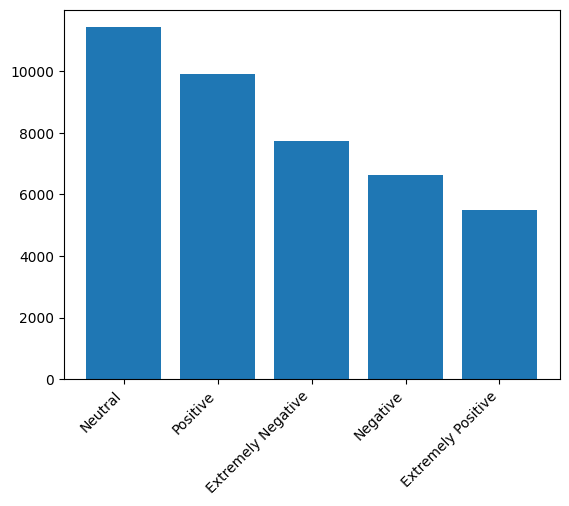

In [4]:
plt.bar(df.Sentiment.unique(), df.Sentiment.value_counts())
plt.xticks(rotation=45, ha='right')
plt.show()

Next, map the sentiment column to a numerical form from 0 - 4, with extremely negative = 0 and extremely positive = 5. Performed with dictionary although could be achived with sklearn via label encoder.

In [5]:
dictmap = {'Extremely Negative': '0', 'Negative': '1', 'Neutral': '2', 'Positive': '3', 'Extremely Positive': '4'}
df['Sentiment'] = df['Sentiment'].map(dictmap)
df['Sentiment'] = df['Sentiment'].astype(int)
df.head()

,Location,TweetAt,OriginalTweet,Sentiment
0,London,16-03-2020,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...,2
1,UK,16-03-2020,advice Talk to your neighbours family to excha...,3
2,Vagabonds,16-03-2020,Coronavirus Australia: Woolworths to give elde...,3
3,NaN,16-03-2020,My food stock is not the only one which is emp...,3
4,NaN,16-03-2020,"Me, ready to go at supermarket during the #COV...",0


For simple text classification based just on the text itself, we only need the OriginalTweet and Sentiment columns.

In [6]:
df = df[['OriginalTweet', 'Sentiment']]
df.head()

,OriginalTweet,Sentiment
0,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...,2
1,advice Talk to your neighbours family to excha...,3
2,Coronavirus Australia: Woolworths to give elde...,3
3,My food stock is not the only one which is emp...,3
4,"Me, ready to go at supermarket during the #COV...",0


Split the training data into 20% validation data.

In [7]:
train, val = np.split(df, [int(0.8 * len(df))])

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [8]:
def df_to_dataset(dataframe, shuffle=True, batch_size=1024):
  df = dataframe.copy()
  labels = df.pop('Sentiment')
  df = df["OriginalTweet"]
  ds = tf.data.Dataset.from_tensor_slices((df, labels))
  if shuffle:
    ds = ds.shuffle(buffer_size=len(dataframe))
  ds = ds.batch(batch_size)
  ds = ds.prefetch(tf.data.AUTOTUNE)
  return ds

loading in the test data (should have done initially).

In [9]:
df2 = pd.read_csv('Corona_NLP_test.csv', encoding='latin-1', usecols=['OriginalTweet', 'Sentiment'])
df2.head()

,OriginalTweet,Sentiment
0,TRENDING: New Yorkers encounter empty supermar...,Extremely Negative
1,When I couldn't find hand sanitizer at Fred Me...,Positive
2,Find out how you can protect yourself and love...,Extremely Positive
3,#Panic buying hits #NewYork City as anxious sh...,Negative
4,#toiletpaper #dunnypaper #coronavirus #coronav...,Neutral


In [10]:
dictmap = {'Extremely Negative': '0', 'Negative': '1', 'Neutral': '2', 'Positive': '3', 'Extremely Positive': '4'}
df2['Sentiment'] = df2['Sentiment'].map(dictmap)
df2['Sentiment'] = df2['Sentiment'].astype(int)
df2.head()

,OriginalTweet,Sentiment
0,TRENDING: New Yorkers encounter empty supermar...,0
1,When I couldn't find hand sanitizer at Fred Me...,3
2,Find out how you can protect yourself and love...,4
3,#Panic buying hits #NewYork City as anxious sh...,1
4,#toiletpaper #dunnypaper #coronavirus #coronav...,2


Now that we have created the train, validation and testing data sets, we can parse them into the df_to_dataset function.

In [11]:
train_set = df_to_dataset(train)
val_set = df_to_dataset(val)
test_set = df_to_dataset(df2)

using premade embedding API that tokenizes the "OriginalTweet" column into a series of numbers that can be better interpreted by the NN. The specific API im using has better compatibility for strings with special characters opposed to the non-normalized variation.

In [12]:
#always ensure the proper verson of tensorflow is being accounted for.
embed = "https://tfhub.dev/google/nnlm-en-dim128-with-normalization/2"
hub_layer = hub.KerasLayer(embed, input_shape=[],
                           dtype=tf.string, trainable = True)

In [ ]:
hub_layer(list(train_set)[0][0])

<tf.Tensor: shape=(1024, 128), dtype=float32, numpy=
array([[-0.44499394, -0.09273567,  0.02951358, ...,  0.07387406,
         0.02427376, -0.22279683],
       [ 0.59874094, -0.17955233,  0.02649662, ..., -0.05757053,
         0.00389794, -0.09612339],
       [ 0.19721158,  0.04723807, -0.02869511, ..., -0.05433887,
        -0.10589134, -0.16994192],
       ...,
       [ 0.18268514, -0.23875435,  0.24060394, ...,  0.17572837,
         0.01279583, -0.04179836],
       [ 0.32870057,  0.1203673 ,  0.08733846, ...,  0.10963589,
         0.34406877, -0.3598905 ],
       [-0.05256212, -0.03576602,  0.2272886 , ...,  0.0973288 ,
        -0.11631801, -0.0090182 ]], dtype=float32)>

Now that the training data has been tokenized, we will create the model so that the data can be used to train the model.

In [ ]:
model = tf_keras.Sequential()
model.add(hub_layer)
model.add(tf_keras.layers.Dense(16, activation='relu'))
model.add(tf_keras.layers.Dense(16, activation='relu'))
model.add(tf_keras.layers.Dense(5, activation='sigmoid'))

Ran into bug here, making sure that tf_keras is installed and loading importing that in after. Basing model on tf_keras opposed to tf.keras now.

In [ ]:
!pip install tf_keras

adding the compiler now which allows me to put the developed model to use. Again, unlike "NFS-TensorFlow_familiarization", I am using tf_keras instead of tf.keras. In addition to this, I am using the simple "CategoricalCrossentropy" loss function.

In [ ]:
model.compile(
    optimizer=tf_keras.optimizers.Adam(learning_rate=0.001),
    loss=tf_keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'])

Now, we will evaluate the untrained model to get a good estimation to what guessing the answers wil give.

In [ ]:
model.evaluate(train_set)

33/33 [==============================] - 1s 19ms/step - loss: 1.6548 - accuracy: 0.1865


[1.6547962427139282, 0.18654517829418182]

In [ ]:
model.evaluate(val_set)

9/9 [==============================] - 0s 18ms/step - loss: 1.6390 - accuracy: 0.2026


[1.638972520828247, 0.2026239037513733]

Outcomes make sense as they are close to 1/5.

training the data with "train_set".

In [ ]:
model.fit(train_set, epochs=5, validation_data=val_set)

Epoch 1/5
33/33 [==============================] - 110s 3s/step - loss: 1.5807 - accuracy: 0.2784 - val_loss: 1.5606 - val_accuracy: 0.3048
Epoch 2/5
33/33 [==============================] - 108s 3s/step - loss: 1.5206 - accuracy: 0.3346 - val_loss: 1.5015 - val_accuracy: 0.3387
Epoch 3/5
33/33 [==============================] - 112s 3s/step - loss: 1.3962 - accuracy: 0.3835 - val_loss: 1.3708 - val_accuracy: 0.3782
Epoch 4/5
33/33 [==============================] - 121s 4s/step - loss: 1.1850 - accuracy: 0.5295 - val_loss: 1.2247 - val_accuracy: 0.4690
Epoch 5/5
33/33 [==============================] - 110s 3s/step - loss: 0.9445 - accuracy: 0.6573 - val_loss: 1.1063 - val_accuracy: 0.5231


Not enough epochs.

In [ ]:
model.fit(train_set, epochs=10, validation_data=val_set)

Epoch 1/10
33/33 [==============================] - 122s 4s/step - loss: 1.5823 - accuracy: 0.2732 - val_loss: 1.5299 - val_accuracy: 0.3117
Epoch 2/10
33/33 [==============================] - 111s 3s/step - loss: 1.4485 - accuracy: 0.3554 - val_loss: 1.3853 - val_accuracy: 0.3856
Epoch 3/10
33/33 [==============================] - 110s 3s/step - loss: 1.2136 - accuracy: 0.4882 - val_loss: 1.2056 - val_accuracy: 0.4879
Epoch 4/10
33/33 [==============================] - 110s 3s/step - loss: 0.9320 - accuracy: 0.6490 - val_loss: 1.0722 - val_accuracy: 0.5454
Epoch 5/10
33/33 [==============================] - 108s 3s/step - loss: 0.7029 - accuracy: 0.7622 - val_loss: 1.0111 - val_accuracy: 0.5816
Epoch 6/10
33/33 [==============================] - 108s 3s/step - loss: 0.5331 - accuracy: 0.8323 - val_loss: 1.0340 - val_accuracy: 0.5862
Epoch 7/10
33/33 [==============================] - 116s 4s/step - loss: 0.4042 - accuracy: 0.8844 - val_loss: 1.0651 - val_accuracy: 0.5931
Epoch 8/10
33

validation accuracy plateaued around 0.58 and the loss at a slow and steady increase, clear signs of overfitting. We will employ many model and data tweaks to remedy that. First, we gather all of our data into a master data frame and repartition it into train, validation and test data.

In [13]:
print(df.tail())
print(df2.tail())

df_mast = pd.concat([df, df2], ignore_index=True)
print(df_mast.tail())

                                           OriginalTweet  Sentiment
41152  Airline pilots offering to stock supermarket s...          2
41153  Response to complaint not provided citing COVI...          0
41154  You know itÂs getting tough when @KameronWild...          3
41155  Is it wrong that the smell of hand sanitizer i...          2
41156  @TartiiCat Well new/used Rift S are going for ...          1
                                          OriginalTweet  Sentiment
3793  Meanwhile In A Supermarket in Israel -- People...          3
3794  Did you panic buy a lot of non-perishable item...          1
3795  Asst Prof of Economics @cconces was on @NBCPhi...          2
3796  Gov need to do somethings instead of biar je r...          0
3797  I and @ForestandPaper members are committed to...          4
                                           OriginalTweet  Sentiment
44950  Meanwhile In A Supermarket in Israel -- People...          3
44951  Did you panic buy a lot of non-perishable item.

Now that we have the master df, we shuffle it and then repartition it into train, validation and test sets.

In [14]:
shuffled = df_mast.sample(frac=1, random_state=123, ignore_index=True)
train2, val2, test2 = np.split(shuffled, [int(0.8 * len(shuffled)), int(0.9 * len(shuffled))])
print(len(train2))
print(len(val2))
print(len(test2))

35964
4495
4496


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [15]:
train_set2 = df_to_dataset(train2)
val_set2 = df_to_dataset(val2)
test_set2 = df_to_dataset(test2)

Now that we should have more representative data sets, we test the previous model again.

In [16]:
#reusing the same model again
embed = "https://tfhub.dev/google/nnlm-en-dim128-with-normalization/2"
hub_layer = hub.KerasLayer(embed, input_shape=[],
                           dtype=tf.string, trainable = True)

In [17]:
model = tf_keras.Sequential()
model.add(hub_layer)
model.add(tf_keras.layers.Dense(16, activation='relu'))
model.add(tf_keras.layers.Dense(16, activation='relu'))
model.add(tf_keras.layers.Dense(5, activation='sigmoid'))

In [18]:
model.compile(
    optimizer=tf_keras.optimizers.Adam(learning_rate=0.001),
    loss=tf_keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'])

testing same model on new training set, should be ~1/5 accuracy.

In [ ]:
model.evaluate(train_set2)

36/36 [==============================] - 1s 13ms/step - loss: 1.6030 - accuracy: 0.2428


[1.6029928922653198, 0.2427983582019806]

training the model on the new data.

In [ ]:
model.fit(train_set2, epochs=10, validation_data=val_set2)

Epoch 1/10
36/36 [==============================] - 64s 2s/step - loss: 1.5691 - accuracy: 0.2637 - val_loss: 1.5365 - val_accuracy: 0.3039
Epoch 2/10
36/36 [==============================] - 64s 2s/step - loss: 1.4582 - accuracy: 0.3661 - val_loss: 1.3943 - val_accuracy: 0.3746
Epoch 3/10
36/36 [==============================] - 63s 2s/step - loss: 1.1822 - accuracy: 0.5301 - val_loss: 1.1478 - val_accuracy: 0.5190
Epoch 4/10
36/36 [==============================] - 75s 2s/step - loss: 0.8432 - accuracy: 0.7084 - val_loss: 1.0062 - val_accuracy: 0.5815
Epoch 5/10
36/36 [==============================] - 66s 2s/step - loss: 0.6017 - accuracy: 0.8082 - val_loss: 0.9867 - val_accuracy: 0.5969
Epoch 6/10
36/36 [==============================] - 65s 2s/step - loss: 0.4427 - accuracy: 0.8681 - val_loss: 1.0118 - val_accuracy: 0.5967
Epoch 7/10
36/36 [==============================] - 65s 2s/step - loss: 0.3330 - accuracy: 0.9097 - val_loss: 1.0627 - val_accuracy: 0.5991
Epoch 8/10
36/36 [==

Over fitting is still an issue, we now move on to rewriting the model slightly. For this tweak we will be adding in "keras_layers.Dropout(0.25)" which deacrivates a random portion (25%) of the neurons for every given step of an epoch in the training process.

In [26]:
model2 = tf_keras.Sequential([
    hub_layer,
    tf_keras.layers.Dense(16, activation='relu'),
    tf_keras.layers.Dropout(0.25),
    tf_keras.layers.Dense(16, activation='relu'),
    tf_keras.layers.Dropout(0.25),
    tf_keras.layers.Dense(5, activation='sigmoid')
])

In [27]:
model2.compile(
    optimizer=tf_keras.optimizers.Adam(learning_rate=0.001),
    loss=tf_keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'])

test the untrained accuracy, should be ~1/5 like the previous tests.

In [28]:
model2.evaluate(train_set2)

36/36 [==============================] - 2s 34ms/step - loss: 1.6096 - accuracy: 0.2395


[1.6096302270889282, 0.23948949575424194]

now train the model.

In [29]:
model2.fit(train_set2, epochs=10, validation_data=val_set2)

Epoch 1/10
36/36 [==============================] - 147s 4s/step - loss: 1.5688 - accuracy: 0.2751 - val_loss: 1.5116 - val_accuracy: 0.3455
Epoch 2/10
36/36 [==============================] - 136s 4s/step - loss: 1.4774 - accuracy: 0.3342 - val_loss: 1.4098 - val_accuracy: 0.4038
Epoch 3/10
36/36 [==============================] - 133s 4s/step - loss: 1.3495 - accuracy: 0.4033 - val_loss: 1.2700 - val_accuracy: 0.4801
Epoch 4/10
36/36 [==============================] - 131s 4s/step - loss: 1.1834 - accuracy: 0.4963 - val_loss: 1.1241 - val_accuracy: 0.5417
Epoch 5/10
36/36 [==============================] - 133s 4s/step - loss: 1.0002 - accuracy: 0.5869 - val_loss: 1.0183 - val_accuracy: 0.5838
Epoch 6/10
36/36 [==============================] - 152s 4s/step - loss: 0.8434 - accuracy: 0.6611 - val_loss: 0.9706 - val_accuracy: 0.6109
Epoch 7/10
36/36 [==============================] - 131s 4s/step - loss: 0.7215 - accuracy: 0.7172 - val_loss: 0.9720 - val_accuracy: 0.6154
Epoch 8/10
36

In [30]:
model2.evaluate(train_set2)

36/36 [==============================] - 23s 617ms/step - loss: 0.2768 - accuracy: 0.9300


[0.27677005529403687, 0.929985523223877]

In [31]:
model2.evaluate(val_set2)

5/5 [==============================] - 2s 438ms/step - loss: 1.1038 - accuracy: 0.6116


[1.1037517786026, 0.6115683913230896]

As seen from the training and the evaluations of the model, introducing the dropout function did help reduce the rate that the model developed overfitting and did help to reduce overall loss of the validation set but did not prevent it all together. Now, we will introduce regularizers.

First, we introduce l2 regularizer to assess the impact it has on our model during and after training.

In [33]:
model3 = tf_keras.Sequential([
    hub_layer,
    tf_keras.layers.Dense(16, activation='relu',
                          kernel_regularizer = tf_keras.regularizers.l2(0.01)),
    tf_keras.layers.Dropout(0.25),
    tf_keras.layers.Dense(16, activation='relu',
                          kernel_regularizer = tf_keras.regularizers.l2(0.01)),
    tf_keras.layers.Dropout(0.25),
    tf_keras.layers.Dense(5, activation='sigmoid')
])

In [34]:
model3.compile(
    optimizer=tf_keras.optimizers.Adam(learning_rate=0.001),
    loss=tf_keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'])

In [35]:
model3.evaluate(train_set2)

36/36 [==============================] - 25s 634ms/step - loss: 2.0519 - accuracy: 0.1728


[2.0519309043884277, 0.17283950746059418]

In [36]:
model3.fit(train_set2, epochs=10, validation_data=val_set2)

Epoch 1/10
36/36 [==============================] - 131s 4s/step - loss: 1.9444 - accuracy: 0.2761 - val_loss: 1.8432 - val_accuracy: 0.3337
Epoch 2/10
36/36 [==============================] - 125s 3s/step - loss: 1.7385 - accuracy: 0.3810 - val_loss: 1.6726 - val_accuracy: 0.4483
Epoch 3/10
36/36 [==============================] - 128s 4s/step - loss: 1.5447 - accuracy: 0.4872 - val_loss: 1.5125 - val_accuracy: 0.5244
Epoch 4/10
36/36 [==============================] - 125s 3s/step - loss: 1.3576 - accuracy: 0.5742 - val_loss: 1.3754 - val_accuracy: 0.5753
Epoch 5/10
36/36 [==============================] - 128s 4s/step - loss: 1.1968 - accuracy: 0.6509 - val_loss: 1.2893 - val_accuracy: 0.6009
Epoch 6/10
36/36 [==============================] - 129s 4s/step - loss: 1.0638 - accuracy: 0.7026 - val_loss: 1.2329 - val_accuracy: 0.6120
Epoch 7/10
36/36 [==============================] - 129s 4s/step - loss: 0.9680 - accuracy: 0.7400 - val_loss: 1.2088 - val_accuracy: 0.6100
Epoch 8/10
36

The model does seem to be avoiding overfitting now as the validation loss is no longer on a general trend up. However, the model can definetly be improved on plenty, lets try l1 regularization.

In [37]:
model4 = tf_keras.Sequential([
    hub_layer,
    tf_keras.layers.Dense(16, activation='relu',
                          kernel_regularizer = tf_keras.regularizers.l1(0.01)),
    tf_keras.layers.Dropout(0.25),
    tf_keras.layers.Dense(16, activation='relu',
                          kernel_regularizer = tf_keras.regularizers.l1(0.01)),
    tf_keras.layers.Dropout(0.25),
    tf_keras.layers.Dense(5, activation='sigmoid')
])

In [39]:
model4.compile(
    optimizer=tf_keras.optimizers.Adam(learning_rate=0.001),
    loss=tf_keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'])

In [40]:
model4.fit(train_set2, epochs=10, validation_data=val_set2)

Epoch 1/10
36/36 [==============================] - 139s 4s/step - loss: 3.8757 - accuracy: 0.2312 - val_loss: 3.4707 - val_accuracy: 0.3061
Epoch 2/10
36/36 [==============================] - 130s 4s/step - loss: 3.1535 - accuracy: 0.3005 - val_loss: 2.8390 - val_accuracy: 0.3502
Epoch 3/10
36/36 [==============================] - 132s 4s/step - loss: 2.5804 - accuracy: 0.3354 - val_loss: 2.3429 - val_accuracy: 0.3617
Epoch 4/10
36/36 [==============================] - 126s 4s/step - loss: 2.1416 - accuracy: 0.3787 - val_loss: 1.9882 - val_accuracy: 0.3835
Epoch 5/10
36/36 [==============================] - 127s 4s/step - loss: 1.8406 - accuracy: 0.4142 - val_loss: 1.7615 - val_accuracy: 0.3956
Epoch 6/10
36/36 [==============================] - 126s 3s/step - loss: 1.6596 - accuracy: 0.4473 - val_loss: 1.6400 - val_accuracy: 0.4162
Epoch 7/10
36/36 [==============================] - 129s 4s/step - loss: 1.5524 - accuracy: 0.4684 - val_loss: 1.5590 - val_accuracy: 0.4238
Epoch 8/10
36

Finally the overfitting issue has been fixed but a clear issue is now present, the overall accuracy has decreased significantly in both training and validation. Because of this, it would be best to go with model3 for this dataset.